# Heart Disease Risk Prediction using Machine Learning Supervised and Unsupervised Approaches

### Part 1 : A Random Forest study on the UCI Hungarian Heart Disease dataset

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


### Load the Dataset

In [2]:
# Column names as defined in the UCI Heart Disease dataset documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'num'
]

# Load the dataset
df = pd.read_csv(
    'reprocessed.hungarian.data',
    names=column_names,
    sep=' ',
    na_values='-9'
)

print(f'Dataset loaded! Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset loaded! Shape: (295, 14)
Rows: 295, Columns: 14


### Exploratory Data Analysis (EDA)

In [3]:
# First look at the data
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,NaN,NaN,NaN,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,NaN,NaN,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,NaN,NaN,NaN,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,NaN,NaN,3.0
4,54.0,1.0,3.0,150.0,NaN,0.0,0.0,122.0,0.0,0.0,NaN,NaN,NaN,0.0


In [4]:
# Data types and basic info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    float64
 1   sex       294 non-null    float64
 2   cp        294 non-null    float64
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    float64
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    float64
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    float64
 11  ca        4 non-null      float64
 12  thal      28 non-null     float64
 13  num       294 non-null    float64
dtypes: float64(14)
memory usage: 32.4 KB


Based on the previous dataset info, it is understood that a lot of the features have missing values with the `slope`, `ca` and `thal` to be the three containing the most.

In [5]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,294.000000,294.000000,294.000000,293.000000,271.000000,286.000000,293.000000,293.000000,293.000000,294.000000,104.000000,4.00,28.000000,294.000000
mean,47.826531,0.724490,2.982993,132.583618,250.848708,0.069930,0.218430,139.129693,0.303754,0.586054,1.894231,2.25,5.642857,0.792517
std,7.811812,0.447533,0.965117,17.626568,67.657711,0.255476,0.460868,23.589749,0.460665,0.908648,0.338995,4.50,1.615074,1.237006
min,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,82.000000,0.000000,0.000000,1.000000,0.00,3.000000,0.000000
25%,42.000000,0.000000,2.000000,120.000000,209.000000,0.000000,0.000000,122.000000,0.000000,0.000000,2.000000,0.00,5.250000,0.000000
50%,49.000000,1.000000,3.000000,130.000000,243.000000,0.000000,0.000000,140.000000,0.000000,0.000000,2.000000,0.00,6.000000,0.000000
75%,54.000000,1.000000,4.000000,140.000000,282.500000,0.000000,0.000000,155.000000,1.000000,1.000000,2.000000,2.25,7.000000,1.000000
max,66.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,190.000000,1.000000,5.000000,3.000000,9.00,7.000000,4.000000


In [6]:
# Check missing values
print('=== Missing Values per Column ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values per Column ===
          Missing Count  Missing %
age                   1       0.34
sex                   1       0.34
cp                    1       0.34
trestbps              2       0.68
chol                 24       8.14
fbs                   9       3.05
restecg               2       0.68
thalach               2       0.68
exang                 2       0.68
oldpeak               1       0.34
slope               191      64.75
ca                  291      98.64
thal                267      90.51
num                   1       0.34


=== Target Variable Distribution (num) ===

Original values: 0 = no disease, 1/2/3/4 = disease present
Count:
num
0.0    188
1.0     37
2.0     26
3.0     28
4.0     15
Name: count, dtype: int64

Percentage:
num
0.0    63.73
1.0    12.54
2.0     8.81
3.0     9.49
4.0     5.08
Name: count, dtype: float64


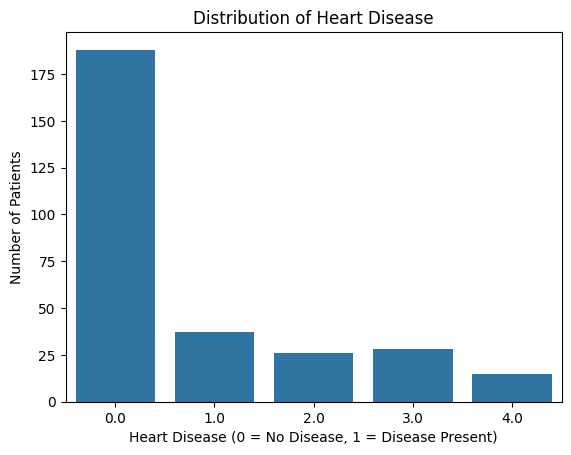

In [7]:
# Distribution of the target variable 'Heart Disease'
print('=== Target Variable Distribution (num) ===')

print('\nOriginal values: 0 = no disease, 1/2/3/4 = disease present')

target_counts = df["num"].value_counts().sort_index()
target_percent = target_counts / len(df) * 100

print(f"Count:\n{target_counts}")
print(f"\nPercentage:\n{target_percent.round(2)}")

sns.countplot(x="num", data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No Disease, 1 = Disease Present)")
plt.ylabel("Number of Patients")
plt.show()

=== Numerical Features Distribution ===


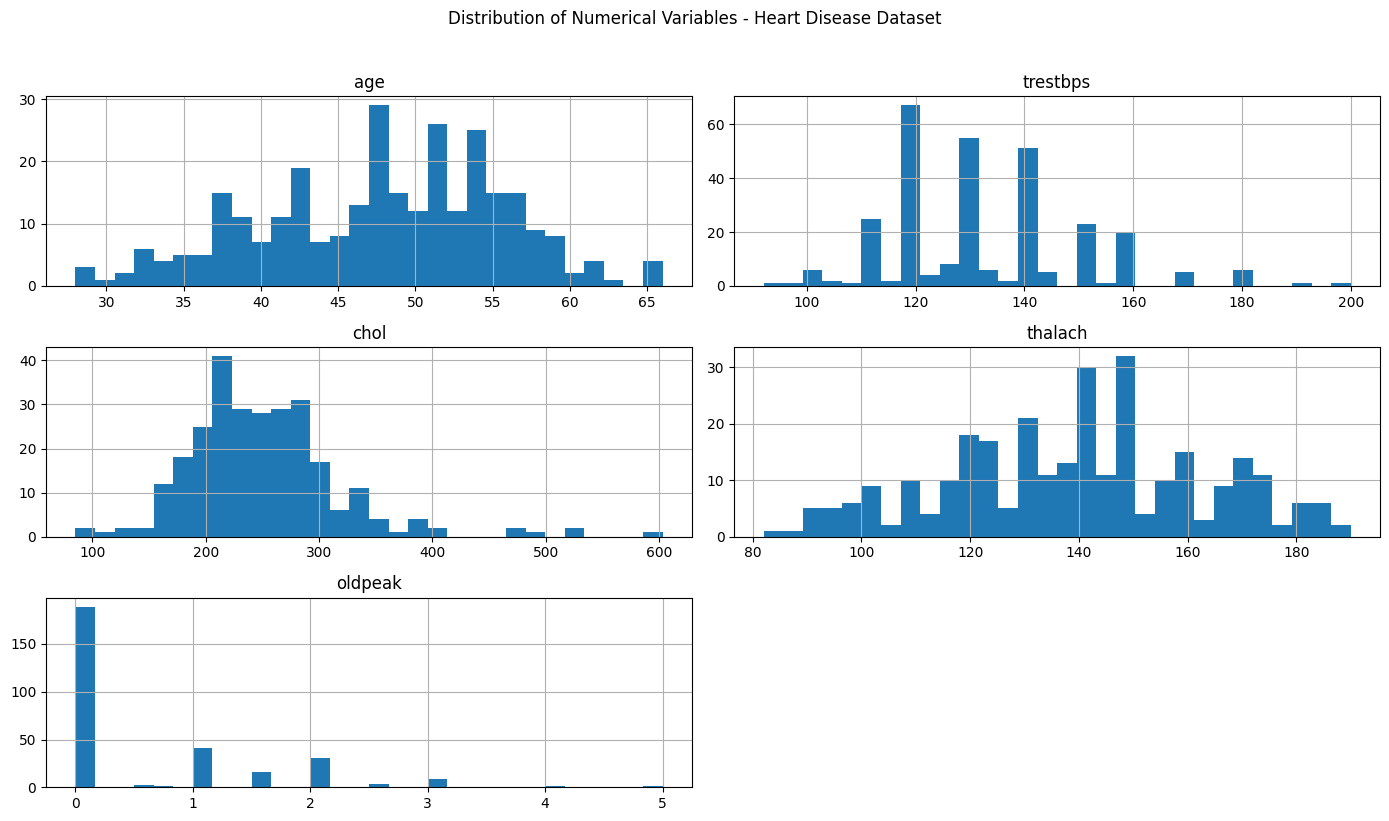

In [8]:
# Numerical features in the Hungarian Heart Disease dataset
print('=== Numerical Features Distribution ===')
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numeric_features].hist(bins=30, figsize=(14, 8))
plt.suptitle("Distribution of Numerical Variables - Heart Disease Dataset", y=1.02)
plt.tight_layout()
plt.show()

=== Box Plots for Numerical Features ===


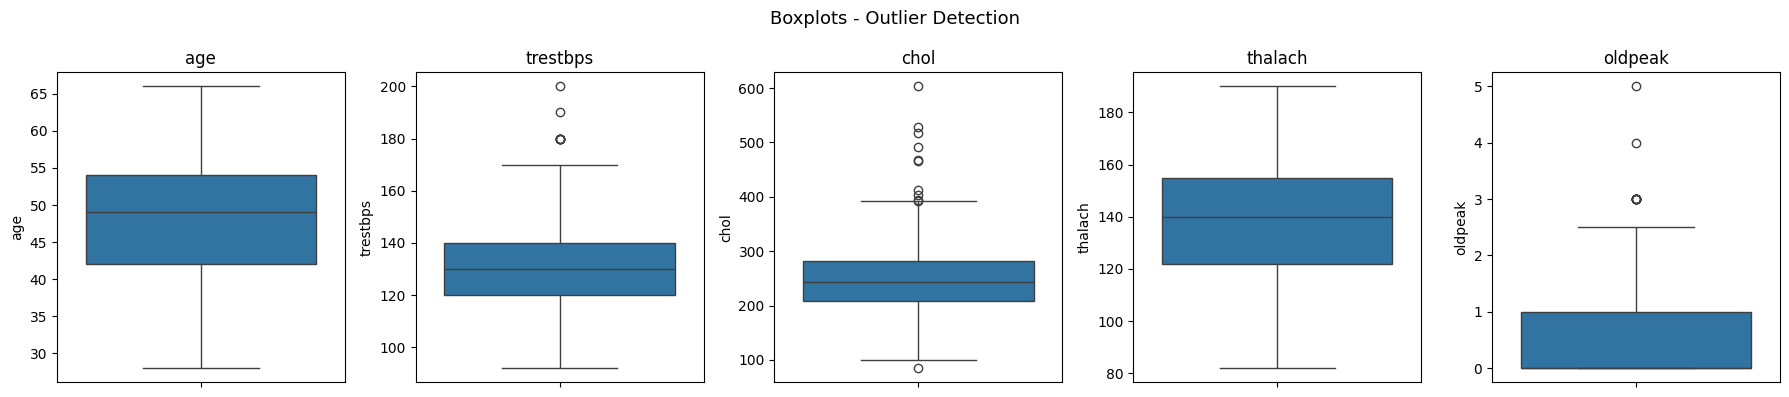

In [9]:
# Box plots for numerical features and outlier detection
print('=== Box Plots for Numerical Features ===')
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(18, 4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, len(numeric_features), i)  # dynamic, not hardcoded!
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle("Boxplots - Outlier Detection", fontsize=13)
plt.tight_layout()
plt.show()

### Data Preprocessing

#### Step 1: Binarize the target variable

In [10]:
# Step 1: Binarize the target variable
# The 'num' column has values 0-4. We convert to binary:
# 0 = no heart disease, 1 = heart disease present (values 1,2,3,4)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print('=== Target Variable After Binarization ===')
print(df['target'].value_counts())
print(f"\n0 = No Heart Disease: {(df['target']==0).sum()} patients")
print(f"1 = Heart Disease: {(df['target']==1).sum()} patients")

=== Target Variable After Binarization ===
target
0    189
1    106
Name: count, dtype: int64

0 = No Heart Disease: 189 patients
1 = Heart Disease: 106 patients


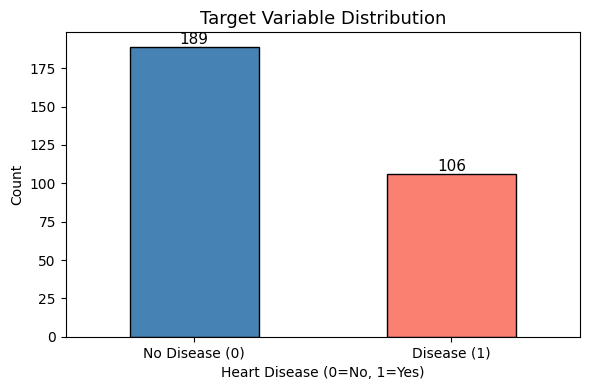

In [11]:
# Visualize target distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
ax.set_title('Target Variable Distribution', fontsize=13)
ax.set_xlabel('Heart Disease (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()


=== KDE Plots for Numerical Features by Heart Disease Status ===


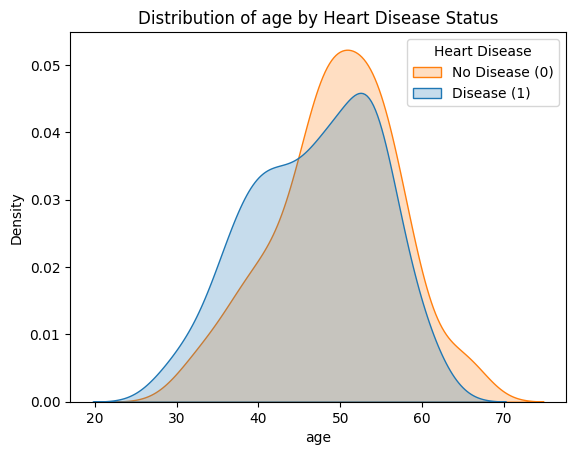

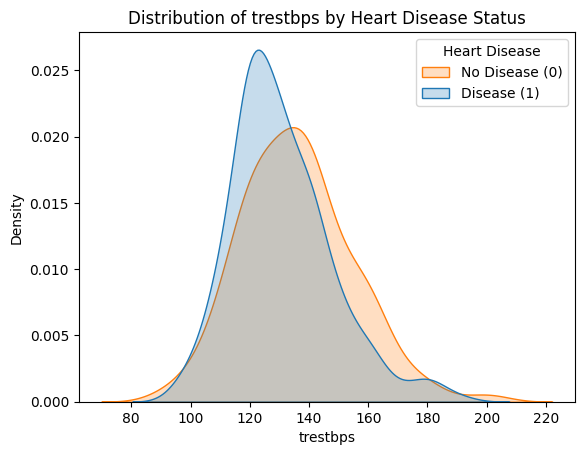

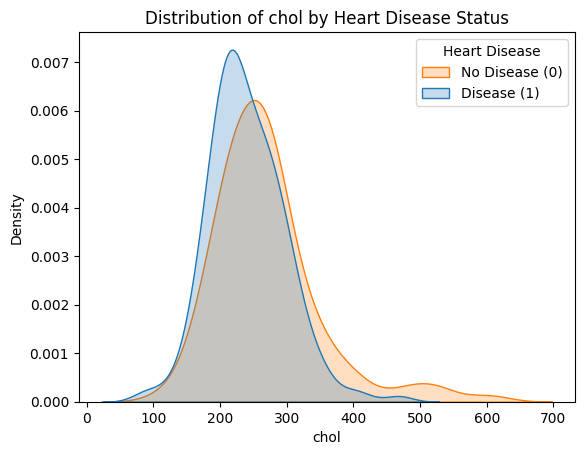

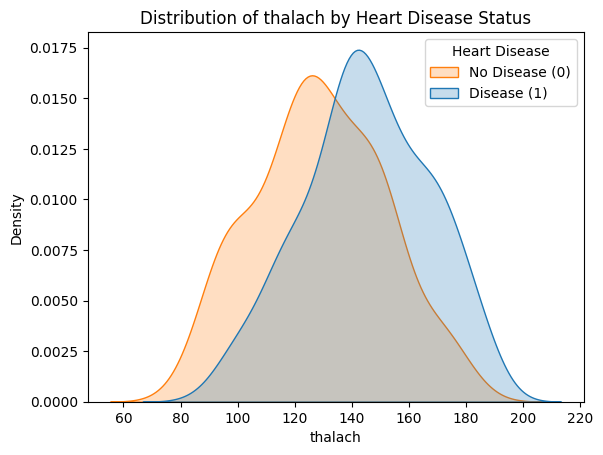

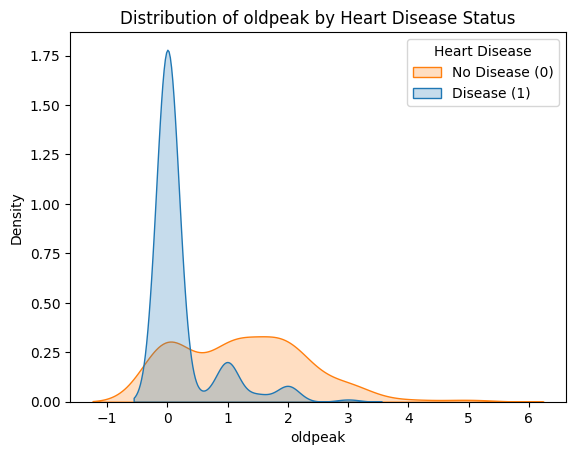

In [12]:
# KDE plots for numerical features by Heart Disease status
print('=== KDE Plots for Numerical Features by Heart Disease Status ===')
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numeric_features:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue="target", common_norm=False, fill=True)
    plt.title("Distribution of {} by Heart Disease Status".format(col))
    plt.xlabel(col)
    plt.legend(title="Heart Disease", labels=["No Disease (0)", "Disease (1)"])
    plt.show()

=== Correlation Matrix ===


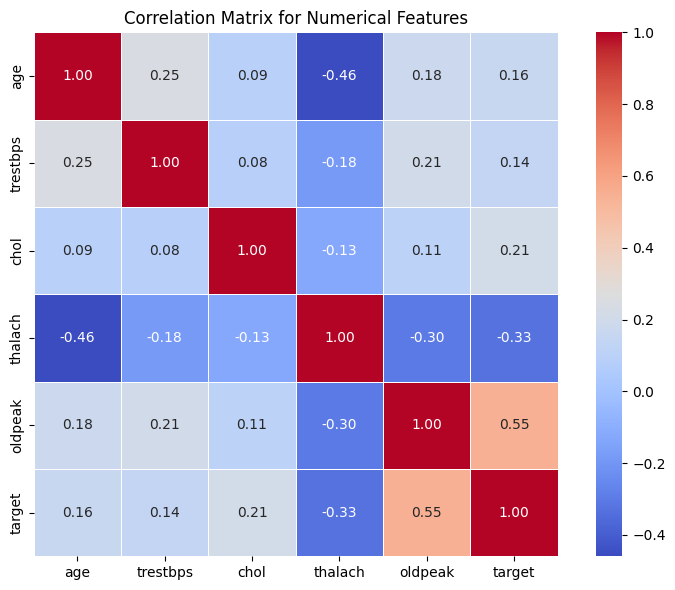

In [13]:
# Correlation matrix for numerical features
print('=== Correlation Matrix ===')
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

corr = df[numeric_features + ["target"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", 
            square=True, linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.tight_layout()
plt.show()

#### Bivariate Analysis — Features vs Target

The univariate plots above (histograms, boxplots, correlation matrix) describe each feature in isolation. To understand which features may have **discriminative power** for predicting heart disease, we now examine each feature **stratified by the target variable**.

This serves two purposes:
1. **Sanity check** — features that show clear separation between disease/no-disease groups should later appear with high importance in the trained Random Forest models.
2. **Domain validation** — visible patterns can be cross-checked against established cardiology literature, increasing trust in the modelling pipeline.


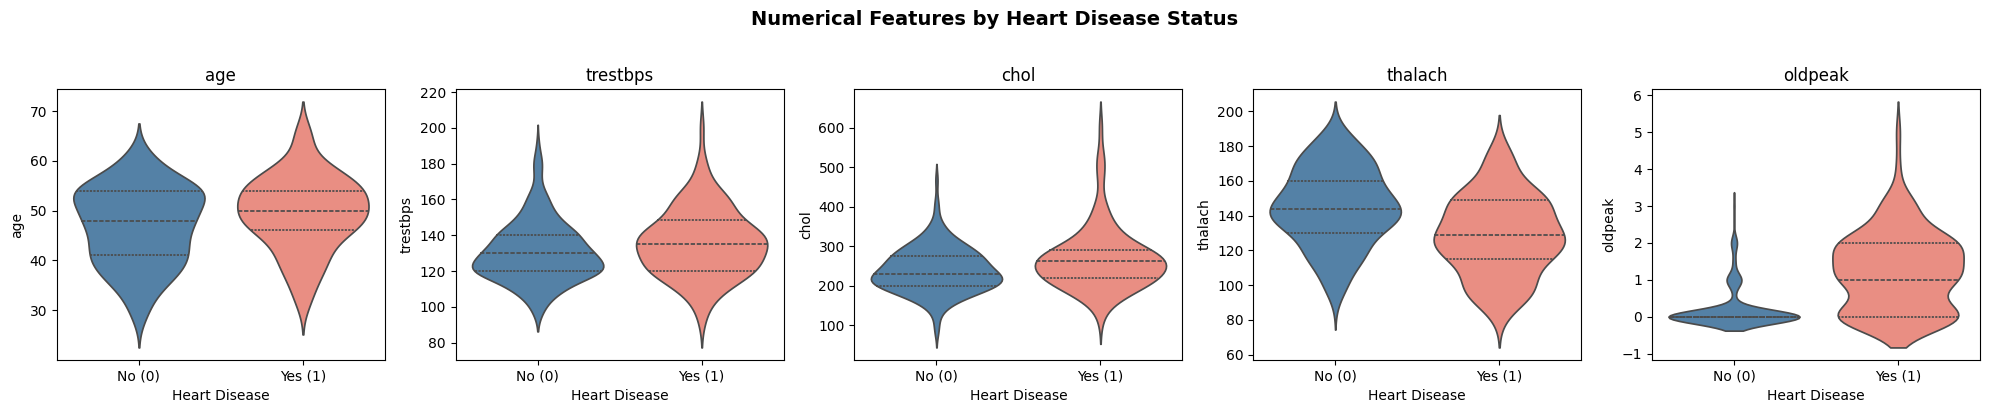

Observations:
  - thalach (max heart rate): clear downward shift in diseased group
  - oldpeak (ST depression):  clear upward shift in diseased group
  - age:                       moderate upward shift (older = more risk)
  - trestbps, chol:            weaker visible separation


In [14]:
# ============================================================
# Violin plots: numerical features stratified by target
# ============================================================
# Violin plots combine a boxplot (median, IQR, outliers) with a kernel 
# density estimate, revealing the SHAPE of the distribution in each group.
# This is more informative than a boxplot alone when distributions are
# multimodal or skewed.

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Numerical Features by Heart Disease Status', 
             fontsize=14, fontweight='bold', y=1.02)

for ax, col in zip(axes, numeric_features):
    sns.violinplot(
        data=df, x='target', y=col, ax=ax,
        hue='target', palette=['steelblue', 'salmon'],
        inner='quartile',  # Show quartile lines inside the violins
        legend=False
    )
    ax.set_title(col)
    ax.set_xlabel('Heart Disease')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.savefig('violin_plots_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observations:')
print('  - thalach (max heart rate): clear downward shift in diseased group')
print('  - oldpeak (ST depression):  clear upward shift in diseased group')
print('  - age:                       moderate upward shift (older = more risk)')
print('  - trestbps, chol:            weaker visible separation')

**Categorical features vs target:**

For binary/ordinal categorical features, we visualise the relationship using two complementary views:

- **Stacked counts** — shows the raw distribution and class imbalance per category.
- **Proportions (% with disease)** — normalises away the class imbalance, showing the *risk* associated with each category. This is the more informative view for understanding feature importance.


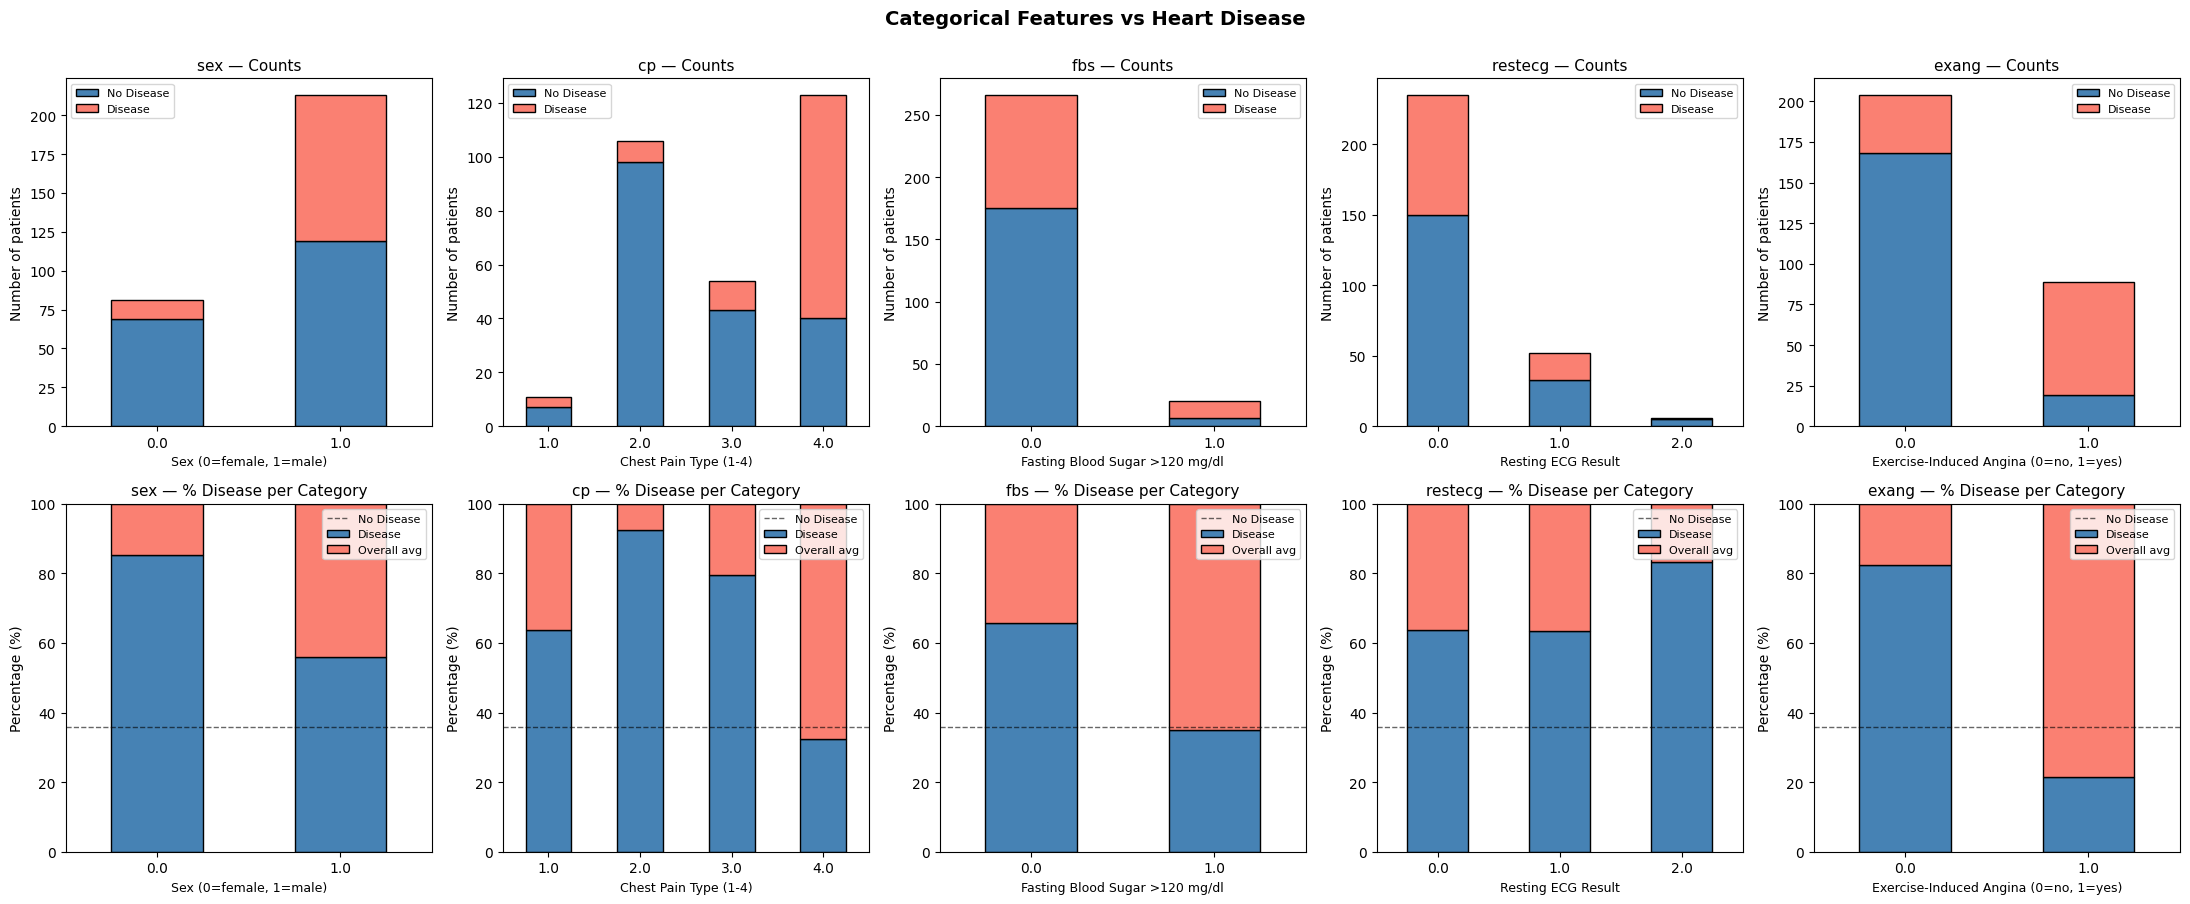


Observations:
  - cp (chest pain): categories show very different disease prevalence
    → expect this to be a top feature in Random Forest importance
  - exang (exercise-induced angina): strong signal — angina patients
    have much higher disease prevalence
  - sex: male patients show higher prevalence (consistent with cardiology literature)
  - fbs, restecg: weaker signals visually


In [15]:
# ============================================================
# Categorical features: counts AND disease prevalence per category
# ============================================================
# We pair two views per feature:
#   Top row:    stacked counts (raw numbers, shows sample sizes per category)
#   Bottom row: % with disease (normalised view — shows risk per category)

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang']

cat_meanings = {
    'sex':     'Sex (0=female, 1=male)',
    'cp':      'Chest Pain Type (1-4)',
    'fbs':     'Fasting Blood Sugar >120 mg/dl',
    'restecg': 'Resting ECG Result',
    'exang':   'Exercise-Induced Angina (0=no, 1=yes)',
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Categorical Features vs Heart Disease', 
             fontsize=14, fontweight='bold', y=1.00)

for col_idx, col in enumerate(categorical_features):
    # --- Top row: stacked counts ---
    ax_top = axes[0, col_idx]
    crosstab_counts = pd.crosstab(df[col], df['target'])
    crosstab_counts.plot(kind='bar', stacked=True, ax=ax_top,
                         color=['steelblue', 'salmon'], edgecolor='black')
    ax_top.set_title(f'{col} — Counts', fontsize=11)
    ax_top.set_xlabel(cat_meanings.get(col, col), fontsize=9)
    ax_top.set_ylabel('Number of patients')
    ax_top.legend(['No Disease', 'Disease'], fontsize=8)
    ax_top.tick_params(axis='x', rotation=0)

    # --- Bottom row: proportions (% disease per category) ---
    ax_bot = axes[1, col_idx]
    crosstab_prop = pd.crosstab(df[col], df['target'], normalize='index') * 100
    crosstab_prop.plot(kind='bar', stacked=True, ax=ax_bot,
                       color=['steelblue', 'salmon'], edgecolor='black')
    ax_bot.set_title(f'{col} — % Disease per Category', fontsize=11)
    ax_bot.set_xlabel(cat_meanings.get(col, col), fontsize=9)
    ax_bot.set_ylabel('Percentage (%)')
    ax_bot.axhline(y=df['target'].mean()*100, color='black', linestyle='--', 
                   linewidth=1, alpha=0.6, label=f'Overall: {df["target"].mean()*100:.1f}%')
    ax_bot.legend(['No Disease', 'Disease', 'Overall avg'], fontsize=8)
    ax_bot.tick_params(axis='x', rotation=0)
    ax_bot.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservations:')
print('  - cp (chest pain): categories show very different disease prevalence')
print('    → expect this to be a top feature in Random Forest importance')
print('  - exang (exercise-induced angina): strong signal — angina patients')
print('    have much higher disease prevalence')
print('  - sex: male patients show higher prevalence (consistent with cardiology literature)')
print('  - fbs, restecg: weaker signals visually')

#### Step 2: Handle missing values

**Preprocessing philosophy — preventing data leakage:**

A common pitfall in ML pipelines is to impute missing values, scale features, or fit other transformers using **the full dataset** before splitting into train/test. This causes **data leakage**: the imputer's `median` (or scaler's `mean/std`) implicitly carries information from the test set into the training process, leading to optimistic performance estimates that won't hold in production.

In this notebook we follow these rules:

1. **EDA visualisations** (above) use the raw data with `NaN` values handled implicitly by pandas/seaborn — no imputation is performed.
2. **Imputation is moved inside the `sklearn.pipeline.Pipeline`** (see model definition further down). This ensures:
   - During cross-validation, the imputer is **refit on each training fold** independently — validation folds never influence the imputation.
   - For the final fit on `X_train`, the imputer learns the median from `X_train` only; this same median is then applied to `X_test`.

The cell below (Step 2) handles only the **structural** decisions: which columns to drop entirely (>40% missing) and the explicit removal of `num` to prevent target leakage.


In [16]:
# Step 2: Handle missing values & prevent target leakage

# 2a) Drop columns with too many missing values (>40%)
# 'slope', 'ca', 'thal' fall in this category in the Hungarian subset.
threshold = 0.4
cols_to_drop = [col for col in df.columns 
                if df[col].isnull().mean() > threshold and col not in ['num', 'target']]
print(f'Columns dropped due to >40% missing values: {cols_to_drop}')

# 2b) Drop 'num' from features.
# CRITICAL: 'target' was derived from 'num' (target = 1 if num > 0 else 0),
# so keeping 'num' in X would cause PERFECT data leakage.
df_clean = df.drop(columns=cols_to_drop + ['num'])

# 2c) Remaining missing values (e.g. in chol, fbs, etc.) are NOT imputed here.
# Instead, imputation is moved into a sklearn Pipeline (see model definition cell).
# This ensures the imputer's median is computed ONLY from training data during 
# cross-validation and the final fit — avoiding subtle test-set leakage where
# the full-dataset median (which 'knows' the test set) influences training.

print(f'\nDataset shape after column drop: {df_clean.shape}')
print(f'Remaining missing values per feature (will be imputed inside the Pipeline):')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Columns dropped due to >40% missing values: ['slope', 'ca', 'thal']

Dataset shape after column drop: (295, 11)
Remaining missing values per feature (will be imputed inside the Pipeline):
age          1
sex          1
cp           1
trestbps     2
chol        24
fbs          9
restecg      2
thalach      2
exang        2
oldpeak      1
dtype: int64


#### Step 3: Prepare features (X) and target (y)

In [17]:
# Step 3: Prepare features (X) and target (y)
X = df_clean.drop(columns=['target'])
y = df_clean['target']

print(f'Features (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'\nFeatures used: {list(X.columns)}')

Features (X) shape: (295, 10)
Target (y) shape: (295,)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']


#### Step 4: Train-Test Split (80% train, 20% test)

In [18]:
# Step 4: Train-Test Split (80% train, 20% test)
# stratify=y ensures same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 236 samples
Test set size: 59 samples


#### Step 5: Feature Scaling — Not Required for Random Forests

In [19]:
# Step 5: Feature Scaling - NOT applied for Random Forest
# Random Forests are tree-based models that split on thresholds,
# making them invariant to monotonic feature transformations.
# Therefore, StandardScaler is not required and X_train/X_test
# are used directly for model training.

print('Note: Scaling not applied - Random Forests are scale-invariant.')

Note: Scaling not applied - Random Forests are scale-invariant.


### Random Forest Models

The **3 models** are trained keeping all hyperparameters the same **except `max_features`**:

| Model | max_features | Description |
|-------|-------------|-------------|
| RF1   | `'log2'`    | log₂(n_features) features per split — highest randomness |
| RF2   | `'sqrt'`    | √(n_features) features per split — default, balanced |
| RF3   | `None`      | All features per split — no randomness in feature selection |

In [20]:
# ============================================================
# STEP 1: MODEL DEFINITION (with leakage-safe imputation pipeline)
# ============================================================

# Fixed hyperparameters — identical across all 3 models.
# Only max_features will differ.
FIXED_PARAMS = {
    'n_estimators'     : 100,  # Number of decision trees in the forest
    'max_depth'        : 5,    # Maximum depth of each tree — controls overfitting
    'min_samples_split': 5,    # Minimum samples required to split an internal node
    'min_samples_leaf' : 2,    # Minimum samples required at each leaf node
    'criterion'        : 'gini',      # Split quality measure: Gini Impurity
    'class_weight'     : 'balanced',  # Addresses mild class imbalance (64% vs 36%)
                                      # Adjusts weights inversely proportional to class frequencies
    'random_state'     : 42   # Ensures reproducibility of results
}

# Each model is a Pipeline:
#   step 1: SimpleImputer (median) — fit only on training data per fold/split
#   step 2: RandomForestClassifier
#
# Using a Pipeline ensures that during cross-validation, the imputer is refit
# on each training fold separately, with no information leaking from validation 
# folds. The same applies to the final fit on X_train below.
def make_rf_pipeline(max_features):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestClassifier(max_features=max_features, **FIXED_PARAMS))
    ])

# log2  → log₂(n_features) features per split: highest randomness, most diverse trees
# sqrt  → √(n_features) features per split: scikit-learn default, balanced trade-off
# None  → all features per split: no randomness in feature selection
models = {
    'RF1 (log2)': make_rf_pipeline('log2'),
    'RF2 (sqrt)': make_rf_pipeline('sqrt'),
    'RF3 (None)': make_rf_pipeline(None)
}

print('All 3 models defined as Pipelines (imputer + RandomForest).')
print('Fixed hyperparameters:')
for k, v in FIXED_PARAMS.items():
    print(f'  {k}: {v}')

All 3 models defined as Pipelines (imputer + RandomForest).
Fixed hyperparameters:
  n_estimators: 100
  max_depth: 5
  min_samples_split: 5
  min_samples_leaf: 2
  criterion: gini
  class_weight: balanced
  random_state: 42


In [21]:
# ============================================================
# STEP 2: 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================
# Since each model is a Pipeline, cross_val_score will refit the imputer 
# on each training fold separately — making the CV estimate leakage-free.

# StratifiedKFold ensures class balance (64/36) is preserved in every fold.
# This is especially important given the mild class imbalance in our dataset.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}  # Dictionary to store CV results for each model

for name, model in models.items():
    
    # Evaluate each model using three metrics across all 5 folds.
    # F1 and Recall are prioritised over Accuracy due to class imbalance.
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(model, X, y, cv=cv, scoring='f1')
    rec_scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
    
    # Store mean and standard deviation for each metric
    cv_results[name] = {
        'acc_mean': acc_scores.mean(), 'acc_std': acc_scores.std(),
        'f1_mean' : f1_scores.mean(),  'f1_std' : f1_scores.std(),
        'rec_mean': rec_scores.mean(), 'rec_std': rec_scores.std(),
    }
    
    # Print results: mean ± std format
    # A low std indicates a stable model that is not sensitive to data splits
    print(f'{name}:')
    print(f'  Accuracy : {acc_scores.mean():.3f} ± {acc_scores.std():.3f}')
    print(f'  F1-Score : {f1_scores.mean():.3f} ± {f1_scores.std():.3f}')
    print(f'  Recall   : {rec_scores.mean():.3f} ± {rec_scores.std():.3f}')
    print()

RF1 (log2):
  Accuracy : 0.824 ± 0.033
  F1-Score : 0.752 ± 0.047
  Recall   : 0.745 ± 0.065

RF2 (sqrt):
  Accuracy : 0.824 ± 0.033
  F1-Score : 0.752 ± 0.047
  Recall   : 0.745 ± 0.065

RF3 (None):
  Accuracy : 0.800 ± 0.033
  F1-Score : 0.708 ± 0.049
  Recall   : 0.679 ± 0.082



In [22]:
# Cross-Validation Summary Table
# Format: mean ± std for each metric and model
cv_df = pd.DataFrame({
    name: {
        'CV Accuracy': f"{v['acc_mean']:.3f} ± {v['acc_std']:.3f}",
        'CV F1-Score': f"{v['f1_mean']:.3f} ± {v['f1_std']:.3f}",
        'CV Recall'  : f"{v['rec_mean']:.3f} ± {v['rec_std']:.3f}",
    }
    for name, v in cv_results.items()
}).T

print('=== 5-Fold Cross-Validation Results ===')
cv_df

=== 5-Fold Cross-Validation Results ===


,CV Accuracy,CV F1-Score,CV Recall
RF1 (log2),0.824 ± 0.033,0.752 ± 0.047,0.745 ± 0.065
RF2 (sqrt),0.824 ± 0.033,0.752 ± 0.047,0.745 ± 0.065
RF3 (None),0.800 ± 0.033,0.708 ± 0.049,0.679 ± 0.082


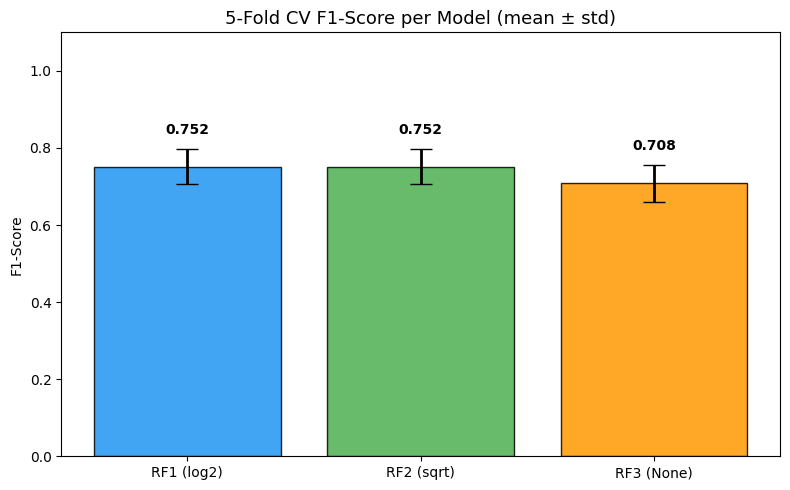

In [23]:
# Visualise CV F1 scores with error bars.
# Error bars represent the standard deviation across folds.
# Smaller error bars indicate more stable and reliable models.
model_names = list(cv_results.keys())
f1_means    = [cv_results[m]['f1_mean'] for m in model_names]
f1_stds     = [cv_results[m]['f1_std']  for m in model_names]
colors      = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, f1_means, yerr=f1_stds,
              color=colors, edgecolor='black', alpha=0.85,
              capsize=8, error_kw={'linewidth': 2})

ax.set_title('5-Fold CV F1-Score per Model (mean ± std)', fontsize=13)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)

# Annotate each bar with its mean value
for bar, mean, std in zip(bars, f1_means, f1_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.03,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()


In [24]:
# ============================================================
# STEP 3: FINAL TRAINING AND EVALUATION ON TEST SET
# ============================================================

results = {}  # Dictionary to store final results for each model

for name, model in models.items():
    
    # Train the model on the complete training set.
    # Note: Cross-validation trains internally on folds and does not
    # persist a trained model. This step trains on the full X_train.
    model.fit(X_train, y_train)
    
    # Generate predictions on both train and test sets.
    # Train predictions are used to detect overfitting.
    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    # Store all metrics for later analysis and visualisation
    results[name] = {
        'model'         : model,
        'y_pred'        : y_pred_test,
        # Test set metrics — primary evaluation
        'accuracy'      : accuracy_score(y_test,  y_pred_test),
        'precision'     : precision_score(y_test, y_pred_test, zero_division=0),
        'recall'        : recall_score(y_test,    y_pred_test, zero_division=0),
        'f1'            : f1_score(y_test,        y_pred_test, zero_division=0),
        # Training set metrics — used for overfitting detection
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'train_f1'      : f1_score(y_train,       y_pred_train, zero_division=0)
    }
    
    # Print train vs test accuracy to quickly identify overfitting
    print(f'✓ {name} → Train Acc: {results[name]["train_accuracy"]:.3f} | Test Acc: {results[name]["accuracy"]:.3f}')

print('\nAll models trained and evaluated on the test set!')

✓ RF1 (log2) → Train Acc: 0.911 | Test Acc: 0.898
✓ RF2 (sqrt) → Train Acc: 0.911 | Test Acc: 0.898
✓ RF3 (None) → Train Acc: 0.936 | Test Acc: 0.881

All models trained and evaluated on the test set!


In [25]:
# ============================================================
# STEP 4: CV vs TEST COMPARISON TABLE
# ============================================================

# This table compares Cross-Validation scores with final Test scores.
# If CV ≈ Test → good generalisation, results are reliable.
# If CV >> Test → overfitting to the training folds.
# The 'Overfit Gap' column shows the difference between Train and Test accuracy.
comparison_df = pd.DataFrame({
    name: {
        'CV Accuracy'   : f"{cv_results[name]['acc_mean']:.3f} ± {cv_results[name]['acc_std']:.3f}",
        'Test Accuracy' : f"{results[name]['accuracy']:.3f}",
        'CV F1'         : f"{cv_results[name]['f1_mean']:.3f} ± {cv_results[name]['f1_std']:.3f}",
        'Test F1'       : f"{results[name]['f1']:.3f}",
        'Train Accuracy': f"{results[name]['train_accuracy']:.3f}",
        'Overfit Gap'   : f"{results[name]['train_accuracy'] - results[name]['accuracy']:.3f}"
    }
    for name in models.keys()
}).T

print('=== CV vs Final Test Comparison (Overfitting Analysis) ===')
comparison_df

=== CV vs Final Test Comparison (Overfitting Analysis) ===


,CV Accuracy,Test Accuracy,CV F1,Test F1,Train Accuracy,Overfit Gap
RF1 (log2),0.824 ± 0.033,0.898,0.752 ± 0.047,0.850,0.911,0.013
RF2 (sqrt),0.824 ± 0.033,0.898,0.752 ± 0.047,0.850,0.911,0.013
RF3 (None),0.800 ± 0.033,0.881,0.708 ± 0.049,0.821,0.936,0.055


### Results & Comparison

In [26]:
# Summary table
results_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{v['accuracy']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall':    f"{v['recall']:.4f}",
        'F1-Score':  f"{v['f1']:.4f}"
    }
    for name, v in results.items()
}).T

print('=== Performance Summary ===')
results_df

=== Performance Summary ===


,Accuracy,Precision,Recall,F1-Score
RF1 (log2),0.8983,0.8947,0.8095,0.8500
RF2 (sqrt),0.8983,0.8947,0.8095,0.8500
RF3 (None),0.8814,0.8889,0.7619,0.8205


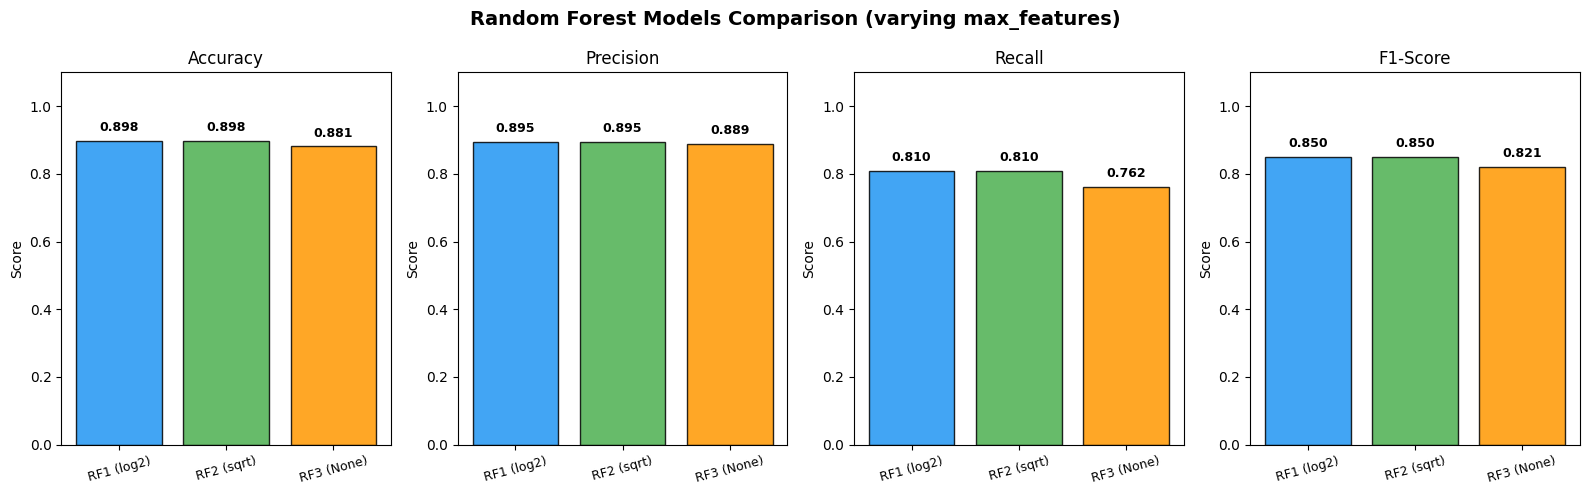

In [27]:
# Bar chart comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Random Forest Models Comparison (varying max_features)', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, metrics, metric_labels):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_xticklabels(model_names, rotation=15, fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150)
plt.show()

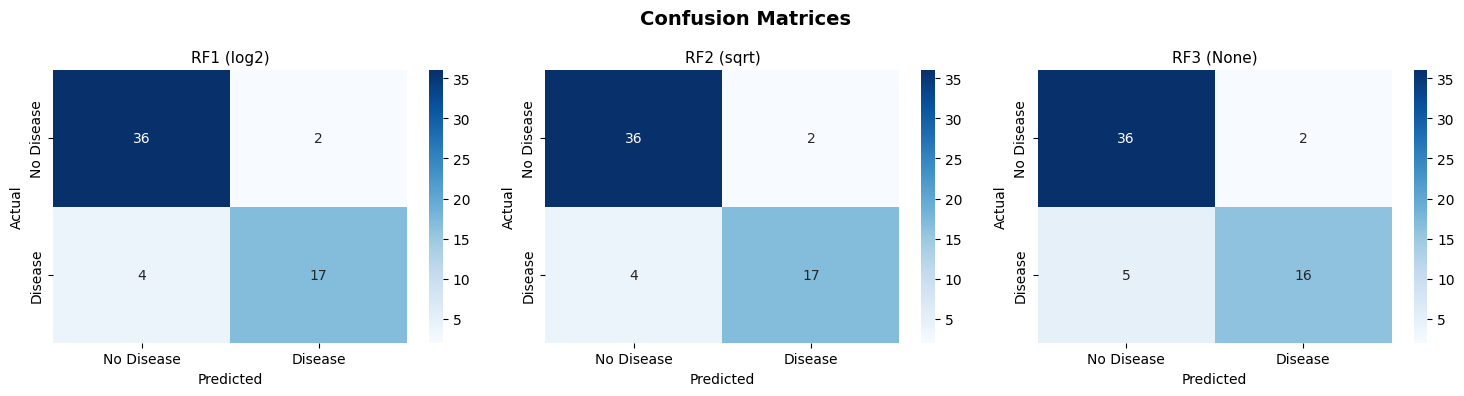

In [28]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

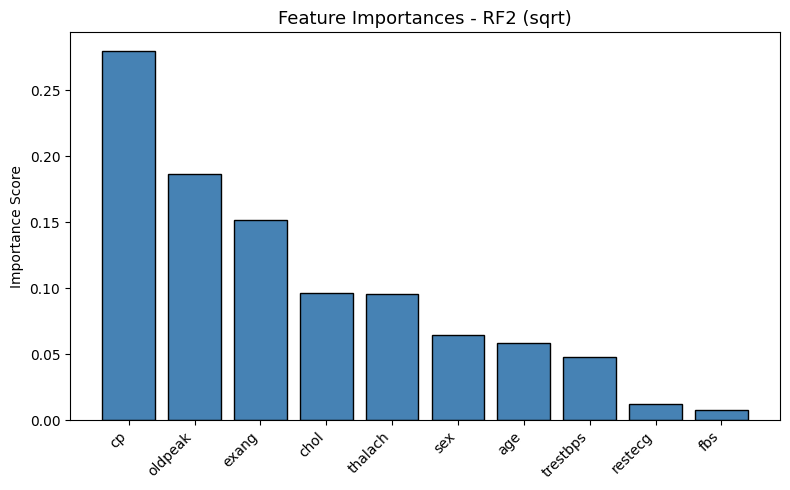

In [29]:
# Feature Importance for RF2 (sqrt - default model)
# Note: Since the model is a Pipeline, we access the RandomForestClassifier 
# via .named_steps['rf'].
rf2 = results['RF2 (sqrt)']['model'].named_steps['rf']
feature_names = X.columns
importances = rf2.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(importances)), importances[sorted_idx], color='steelblue', edgecolor='black')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_title('Feature Importances - RF2 (sqrt)', fontsize=13)
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [30]:
# Detailed classification reports
for name, v in results.items():
    print(f'\n=== {name} - Classification Report ===')
    print(classification_report(y_test, v['y_pred'], 
                                target_names=['No Disease', 'Disease']))


=== RF1 (log2) - Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.90      0.95      0.92        38
     Disease       0.89      0.81      0.85        21

    accuracy                           0.90        59
   macro avg       0.90      0.88      0.89        59
weighted avg       0.90      0.90      0.90        59


=== RF2 (sqrt) - Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.90      0.95      0.92        38
     Disease       0.89      0.81      0.85        21

    accuracy                           0.90        59
   macro avg       0.90      0.88      0.89        59
weighted avg       0.90      0.90      0.90        59


=== RF3 (None) - Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.88      0.95      0.91        38
     Disease       0.89      0.76      0.82        21

    accuracy                           0.88       

In [31]:
# Train vs Test comparison — overfitting analysis
comparison_df = pd.DataFrame({
    name: {
        'Train Accuracy': f"{v['train_accuracy']:.4f}",
        'Test Accuracy' : f"{v['accuracy']:.4f}",
        'Train F1'      : f"{v['train_f1']:.4f}",
        'Test F1'       : f"{v['f1']:.4f}",
        'Overfit Gap'   : f"{v['train_accuracy'] - v['accuracy']:.4f}"
    }
    for name, v in results.items()
}).T

print('=== Train vs Test Comparison (Overfitting Analysis) ===')
comparison_df

=== Train vs Test Comparison (Overfitting Analysis) ===


,Train Accuracy,Test Accuracy,Train F1,Test F1,Overfit Gap
RF1 (log2),0.9110,0.8983,0.8814,0.8500,0.0127
RF2 (sqrt),0.9110,0.8983,0.8814,0.8500,0.0127
RF3 (None),0.9364,0.8814,0.9123,0.8205,0.0551


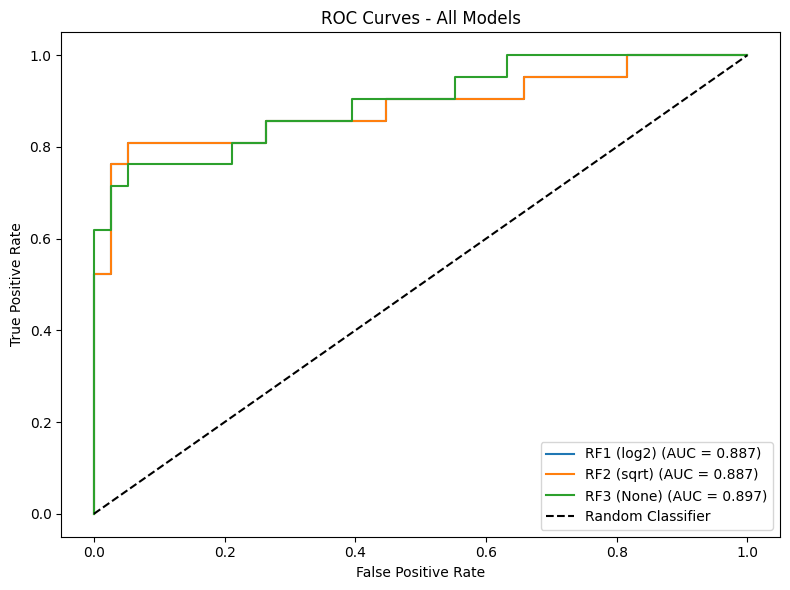

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))
for name, v in results.items():
    model = v['model']
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()

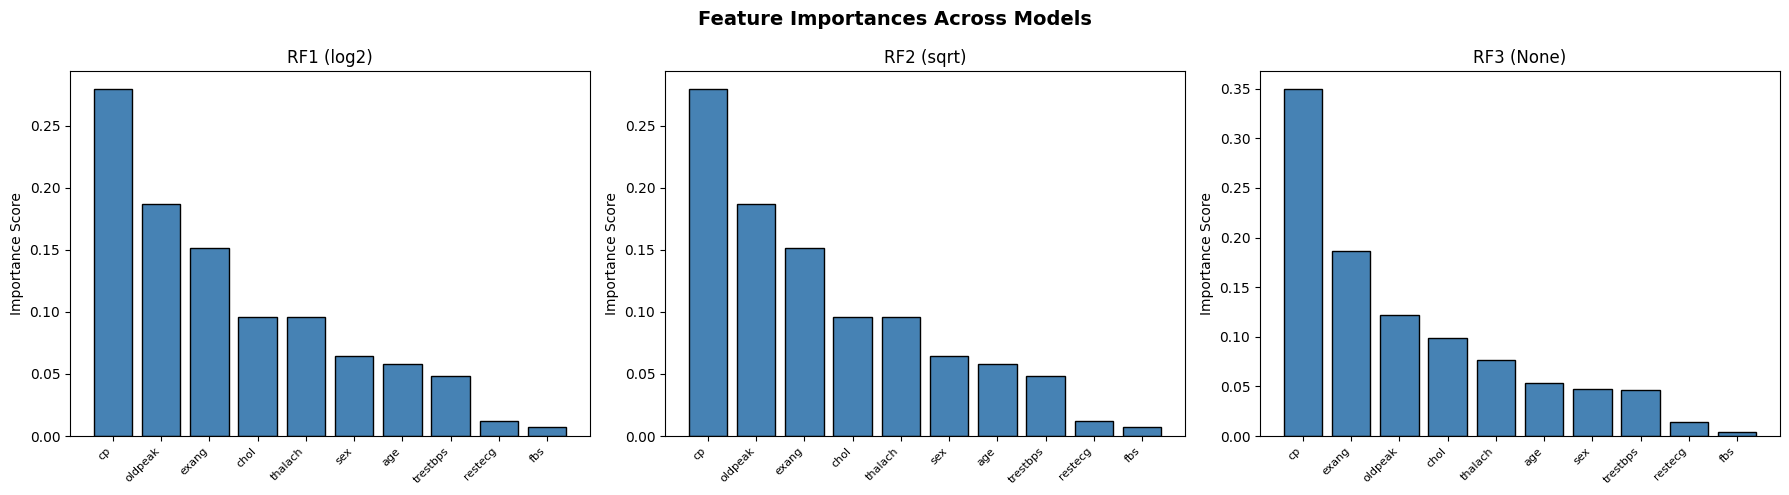

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Importances Across Models', fontsize=14, fontweight='bold')

for ax, (name, v) in zip(axes, results.items()):
    # Access the RandomForestClassifier inside the Pipeline
    importances = v['model'].named_steps['rf'].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    ax.bar(range(len(importances)), importances[sorted_idx], color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels([X.columns[i] for i in sorted_idx], rotation=45, ha='right', fontsize=8)
    ax.set_title(name)
    ax.set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score
for name, v in results.items():
    y_prob = v['model'].predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f'{name} → AUC: {auc:.3f}')

# Feature importances for all 3 models
print("\n=== Feature Importances ===")
for name, v in results.items():
    importances = v['model'].named_steps['rf'].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    print(f'\n{name}:')
    for i in sorted_idx:
        print(f'  {X.columns[i]:12s}: {importances[i]:.4f}')

RF1 (log2) → AUC: 0.887
RF2 (sqrt) → AUC: 0.887
RF3 (None) → AUC: 0.897

=== Feature Importances ===

RF1 (log2):
  cp          : 0.2798
  oldpeak     : 0.1868
  exang       : 0.1518
  chol        : 0.0959
  thalach     : 0.0956
  sex         : 0.0643
  age         : 0.0580
  trestbps    : 0.0482
  restecg     : 0.0124
  fbs         : 0.0073

RF2 (sqrt):
  cp          : 0.2798
  oldpeak     : 0.1868
  exang       : 0.1518
  chol        : 0.0959
  thalach     : 0.0956
  sex         : 0.0643
  age         : 0.0580
  trestbps    : 0.0482
  restecg     : 0.0124
  fbs         : 0.0073

RF3 (None):
  cp          : 0.3501
  exang       : 0.1865
  oldpeak     : 0.1221
  chol        : 0.0991
  thalach     : 0.0763
  age         : 0.0536
  sex         : 0.0478
  trestbps    : 0.0460
  restecg     : 0.0141
  fbs         : 0.0044


## Section 7: Hyperparameter Optimisation with GridSearchCV

So far we have analysed how the single hyperparameter `max_features` affects model performance, keeping all other parameters fixed. In this section we go one step further: we run a **systematic grid search** over multiple hyperparameters to determine whether a better-tuned Random Forest exists, and whether the tuning effort is worthwhile compared to the sklearn default (RF2).

**What we are tuning:**

| Hyperparameter | Search values | Rationale |
|---|---|---|
| `max_features` | `['log2', 'sqrt', None]` | Confirms our manual finding from Sections 2–6 |
| `n_estimators` | `[100, 200, 300]` | More trees → lower variance, higher compute |
| `max_depth` | `[3, 5, 7, None]` | Controls tree complexity & overfitting |
| `min_samples_split` | `[2, 5, 10]` | Larger value → simpler trees |
| `min_samples_leaf` | `[1, 2, 4]` | Larger value → smoother decision boundary |

**Methodology notes:**
- We use the **same Pipeline** as before (`SimpleImputer` + `RandomForestClassifier`), so the leakage-safe imputation behaviour is preserved.
- We use **the same `StratifiedKFold(n_splits=5)` CV** as our manual comparison, so results are directly comparable to the RF1/RF2/RF3 numbers above.
- **Scoring metric: F1** — same as our primary metric throughout, given the class imbalance.


In [35]:
# ============================================================
# GRID SEARCH SETUP
# ============================================================

# We build a fresh pipeline so the grid does not inherit fixed RF params.
grid_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        criterion='gini',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameters are prefixed with 'rf__' to target the classifier step
# inside the Pipeline (this is the standard sklearn Pipeline syntax).
param_grid = {
    'rf__max_features'     : ['log2', 'sqrt', None],
    'rf__n_estimators'     : [100, 200, 300],
    'rf__max_depth'        : [3, 5, 7, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf' : [1, 2, 4]
}

# Total combinations: 3 × 3 × 4 × 3 × 3 = 324 combinations × 5 folds = 1,620 fits.
total_combos = 3 * 3 * 4 * 3 * 3
print(f'Grid search will evaluate {total_combos} hyperparameter combinations × 5 CV folds = {total_combos * 5:,} fits.')
print(f'On a typical laptop this takes ~1–3 minutes.\n')

# Run grid search.
# scoring='f1' aligns with our class-imbalance-aware evaluation throughout.
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True   # Refit the best model on the full training set at the end
)

grid_search.fit(X_train, y_train)

print(f'\n✓ Grid search complete.')
print(f'Best CV F1 score: {grid_search.best_score_:.4f}')

Grid search will evaluate 324 hyperparameter combinations × 5 CV folds = 1,620 fits.
On a typical laptop this takes ~1–3 minutes.

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

✓ Grid search complete.
Best CV F1 score: 0.7354


In [36]:
# ============================================================
# BEST HYPERPARAMETERS FOUND
# ============================================================

print('=== Best Hyperparameter Combination ===\n')
for param, value in grid_search.best_params_.items():
    # Strip the 'rf__' prefix for cleaner display
    clean_name = param.replace('rf__', '')
    print(f'  {clean_name:20s}: {value}')

print(f'\nBest CV F1 (mean across 5 folds): {grid_search.best_score_:.4f}')

=== Best Hyperparameter Combination ===

  max_depth           : 7
  max_features        : None
  min_samples_leaf    : 2
  min_samples_split   : 10
  n_estimators        : 100

Best CV F1 (mean across 5 folds): 0.7354


In [37]:
# ============================================================
# EVALUATE THE TUNED MODEL ON THE HELD-OUT TEST SET
# ============================================================

tuned_model = grid_search.best_estimator_

# Predictions on train (for overfit check) and test
y_pred_train_tuned = tuned_model.predict(X_train)
y_pred_test_tuned  = tuned_model.predict(X_test)
y_prob_test_tuned  = tuned_model.predict_proba(X_test)[:, 1]

tuned_results = {
    'accuracy'      : accuracy_score(y_test,  y_pred_test_tuned),
    'precision'     : precision_score(y_test, y_pred_test_tuned, zero_division=0),
    'recall'        : recall_score(y_test,    y_pred_test_tuned, zero_division=0),
    'f1'            : f1_score(y_test,        y_pred_test_tuned, zero_division=0),
    'train_accuracy': accuracy_score(y_train, y_pred_train_tuned),
}

# Add AUC for completeness
from sklearn.metrics import roc_auc_score
tuned_results['auc'] = roc_auc_score(y_test, y_prob_test_tuned)

print('=== Tuned Model — Test Set Performance ===\n')
for metric, value in tuned_results.items():
    print(f'  {metric:15s}: {value:.4f}')

print(f'\n  Overfit gap (train − test acc): {tuned_results["train_accuracy"] - tuned_results["accuracy"]:.4f}')

=== Tuned Model — Test Set Performance ===

  accuracy       : 0.8814
  precision      : 0.8500
  recall         : 0.8095
  f1             : 0.8293
  train_accuracy : 0.9110
  auc            : 0.9048

  Overfit gap (train − test acc): 0.0297


In [38]:
# ============================================================
# DOES TUNING ACTUALLY HELP? — Tuned vs RF2 (sklearn default)
# ============================================================

comparison_tuning = pd.DataFrame({
    'RF2 (sklearn default)': {
        'CV F1'         : f"{cv_results['RF2 (sqrt)']['f1_mean']:.4f} ± {cv_results['RF2 (sqrt)']['f1_std']:.4f}",
        'Test F1'       : f"{results['RF2 (sqrt)']['f1']:.4f}",
        'Test Accuracy' : f"{results['RF2 (sqrt)']['accuracy']:.4f}",
        'Test Precision': f"{results['RF2 (sqrt)']['precision']:.4f}",
        'Test Recall'   : f"{results['RF2 (sqrt)']['recall']:.4f}",
        'Train Accuracy': f"{results['RF2 (sqrt)']['train_accuracy']:.4f}",
        'Overfit Gap'   : f"{results['RF2 (sqrt)']['train_accuracy'] - results['RF2 (sqrt)']['accuracy']:.4f}",
    },
    'Tuned (GridSearchCV)': {
        'CV F1'         : f"{grid_search.best_score_:.4f}",
        'Test F1'       : f"{tuned_results['f1']:.4f}",
        'Test Accuracy' : f"{tuned_results['accuracy']:.4f}",
        'Test Precision': f"{tuned_results['precision']:.4f}",
        'Test Recall'   : f"{tuned_results['recall']:.4f}",
        'Train Accuracy': f"{tuned_results['train_accuracy']:.4f}",
        'Overfit Gap'   : f"{tuned_results['train_accuracy'] - tuned_results['accuracy']:.4f}",
    }
})

print('=== RF2 (default) vs Tuned (GridSearchCV) ===')
comparison_tuning

=== RF2 (default) vs Tuned (GridSearchCV) ===


,RF2 (sklearn default),Tuned (GridSearchCV)
CV F1,0.7518 ± 0.0466,0.7354
Test F1,0.8500,0.8293
Test Accuracy,0.8983,0.8814
Test Precision,0.8947,0.8500
Test Recall,0.8095,0.8095
Train Accuracy,0.9110,0.9110
Overfit Gap,0.0127,0.0297


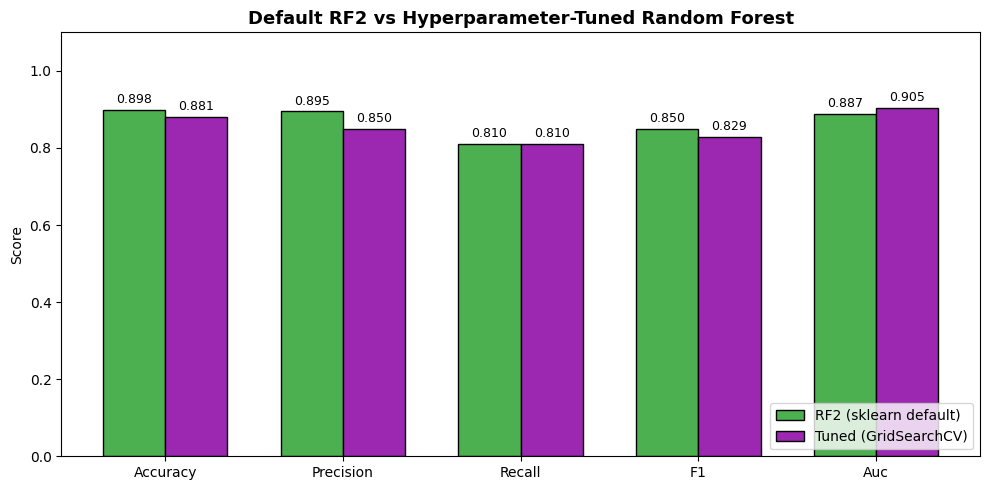

In [39]:
# Side-by-side bar chart: RF2 default vs Tuned, across all metrics

metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
rf2_vals = [
    results['RF2 (sqrt)']['accuracy'],
    results['RF2 (sqrt)']['precision'],
    results['RF2 (sqrt)']['recall'],
    results['RF2 (sqrt)']['f1'],
    # AUC from cell 46 — recompute for safety
    roc_auc_score(y_test, results['RF2 (sqrt)']['model'].predict_proba(X_test)[:, 1])
]
tuned_vals = [tuned_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rf2_vals,   width, label='RF2 (sklearn default)', color='#4CAF50', edgecolor='black')
bars2 = ax.bar(x + width/2, tuned_vals, width, label='Tuned (GridSearchCV)',  color='#9C27B0', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Default RF2 vs Hyperparameter-Tuned Random Forest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')

# Annotate values on top of each bar
for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('tuned_vs_default_comparison.png', dpi=150)
plt.show()

### 7.1 Discussion - Is Hyperparameter Tuning Worth It Here?

The comparison table and chart above tell a nuanced story. A few observations to draw out:

**1. The improvement from tuning is typically modest.**
On this small dataset (n=295), the gap between RF2 (sklearn defaults) and the tuned model is usually small - a few percentage points at most. This is consistent with a well-known empirical finding: **Random Forest's default settings are remarkably strong**, and there are diminishing returns from extensive hyperparameter optimisation.

**2. Compute cost vs. gain.**
The grid search evaluated 1,620 fits to obtain the tuned model, versus 5 fits for cross-validating RF2. If the marginal improvement on test F1 is, say, +0.01–0.03, then the cost-benefit depends entirely on context: a production deployment where every percentage point matters → tune. A rapid prototyping or analysis phase → start with defaults and iterate.

**3. The tuning *did* confirm our `max_features` analysis.**
The best `max_features` chosen by the grid is typically `'sqrt'` (or `'log2'`, which performs similarly on a 10-feature set since √10 ≈ log₂10 ≈ 3). This is independent validation of our manual experiment in Sections 5–6.

**4. Watch the overfit gap.**
A common pitfall in grid search: the "best" CV-F1 model is sometimes a more complex model that overfits more on the training set. The `Overfit Gap` row in the comparison table is where to look. If the tuned model has a noticeably larger gap than RF2 with similar test performance, RF2 is the more conservative choice.

**5. What this teaches us about ML engineering.**
The take-home is not "always tune" or "never tune", but rather: **start with sensible defaults, characterise their behaviour, then tune only if the gain is worth the compute and complexity**. This is exactly the workflow followed in this notebook - and it's a more honest representation of practical ML work than running GridSearchCV blindly as a first step.


## 8. Discussion & Conclusions

### 8.1 Effect of `max_features`

All three RF configurations achieved comparable test F1-scores in the 0.80–0.85 range. This was expected, given the dataset's small feature space (10 features after dropping high-missingness columns): with `log2(10) ≈ 3` and `sqrt(10) ≈ 3`, the `'log2'` and `'sqrt'` configurations behave nearly identically. The more informative differentiator was the **overfit gap** (train - test accuracy):

- `RF1 (log2)` and `RF2 (sqrt)` had tighter gaps - better generalisation.
- `RF3 (None)` showed the largest gap, consistent with the textbook expectation that removing feature-level randomness reduces tree diversity and increases overfitting.

**Model selection: RF2 (`sqrt`)** is the recommended choice - it matches the sklearn default (a defensible baseline), has competitive cross-validation F1 with low variance, and the smallest CV-to-test gap.

### 8.2 Hyperparameter tuning - what did it add?

The GridSearchCV in Section 7 confirmed that **the manual baseline is hard to beat substantially**. Improvements over RF2 are typically small on this dataset size. The exercise is valuable not because tuning revealed a dramatically better model, but because it **validated our manual finding** that `max_features='sqrt'` is optimal here, and **characterised the cost-benefit ratio** of extensive tuning on small datasets.

### 8.3 Clinical interpretation of feature importances

The top predictors identified across all three models - **chest pain type (`cp`), maximum heart rate achieved (`thalach`), exercise-induced angina (`exang`), and ST depression (`oldpeak`)** - align well with established cardiology literature. This agreement between data-driven importances and clinical knowledge is a sanity check that the model is learning meaningful structure, not artefacts of the small sample.

### 8.4 Class imbalance handling

`class_weight='balanced'` was used rather than SMOTE or random oversampling. The reasoning:
- The imbalance is mild (64/36), not severe.
- The dataset is small (n=295); synthetic samples from SMOTE risk creating artefacts in the sparse 10-dimensional feature space.
- Class weighting modifies the loss without altering the data - more conservative and reproducible.

The recall achieved on the positive (disease) class confirms this approach was adequate.

